# EDU-01 — Student Learning Segmentation

## Problem

An online education platform currently gives every student the same generic
support, regardless of how differently they actually behave in the course.
Some students consistently raise hands, visit course resources, check
announcements, and join discussions, while others show low or irregular
engagement — but because the platform has no systematic way to tell these
groups apart, disengagement often goes unnoticed until it shows up in poor
grades. Educators and product teams need a data-driven way to identify
distinct learner behaviors so they can design targeted interventions instead
of one-size-fits-all communication.

## Background

This project uses the **xAPI-Edu-Data** dataset (Students' Academic
Performance Dataset, 480 students, Kaggle, CC BY-SA 4.0), which records each
student's behavioral engagement (participation, resource visits,
announcement views, discussion activity), demographic information, and
final academic performance band (`Class`: Low/Middle/High). Because there is
no existing "learner type" label in the data, this is framed as an
**unsupervised learning problem**: the goal is to discover natural groups of
students from their behavior alone, not to predict a known outcome. The
`Class` column is deliberately excluded from model training — it is reserved
for interpreting the discovered groups afterward, since using it during
clustering would leak the very outcome the segmentation is meant to explain.

## What this notebook implements

Working from raw data to a deployable inference step, this notebook:

1. Loads and validates the dataset, and documents preprocessing decisions
   (dropping the redundant `PlaceofBirth` column, one-hot encoding
   categorical features, standardizing the four numeric behavioral
   features) — fit only on a training split, to avoid leakage into a
   held-out test set of "unseen" students.
2. Establishes **baselines** before trusting any real model:
   - A **naive baseline** (random cluster assignment) to confirm real
     structure exists in the data.
   - A **simple baseline** (K-Means with a minimal k=2).
3. Runs the **main experiment grid**: K-Means across k = 2 to 8, evaluated
   with the **Elbow Method** (inertia) and **Silhouette Score**, then
   compares K-Means against two alternative clustering approaches —
   **Agglomerative (Ward) Clustering** and **DBSCAN** — at the selected k.
4. Checks **cluster stability** by re-fitting the final model across 5
   different random seeds and measuring the **Adjusted Rand Index (ARI)**
   between runs.
5. Selects and justifies a **final model**, evaluates it on a held-out test
   set of students never used during fitting (reporting **Silhouette**,
   **Calinski-Harabasz**, and **Davies-Bouldin** scores on both splits), and
   performs **error analysis** to flag borderline or poorly-fit students.
6. Names and interprets the resulting clusters as actionable learner
   profiles, and cross-checks them against the real `Class` outcome
   (never used in training) as a sanity check.
7. Provides a simple inference function that assigns a brand-new,
   unseen student to a learner segment, with input validation.

**Metrics used:** Silhouette Score (primary), Calinski-Harabasz Index,
Davies-Bouldin Index, inertia (Elbow Method), and Adjusted Rand Index
(stability). **Key parameters explored:** number of clusters k (2–8),
clustering algorithm (K-Means vs. Agglomerative vs. DBSCAN), and DBSCAN's
`eps`/`min_samples`. **Baselines:** random-assignment clustering and a
minimal K-Means (k=2) configuration.

## Step 1 — Get the project files into this Colab session

In [11]:
import os
import subprocess
from google.colab import files
import zipfile

# --- CONFIGURATION: SET YOUR GITHUB REPO URL HERE ---
# IMPORTANT: Replace "YOUR_GITHUB_REPO_URL_HERE" with the actual URL of your GitHub repository.
# Example: GITHUB_REPO_URL = "https://github.com/your_username/your_repo_name.git"
GITHUB_REPO_URL = "https://github.com/qwedrfgvbnvgfdrew/Final_Capstone_Project.git"

# --- DO NOT MODIFY BELOW THIS LINE ---

REPO_TARGET_DIR = "capstone-project" # The directory name where the project files will reside

def setup_project_files():
    # 1. Check if the project is already set up (either from a previous run or a successful clone/extract)
    if os.path.exists(REPO_TARGET_DIR) and os.path.exists(os.path.join(REPO_TARGET_DIR, "src")):
        print(f"Project files already present in '{REPO_TARGET_DIR}' -- skipping setup.")
        return
    elif os.path.exists("src"): # Check for cases where zip extracted directly to root
        print("Project files (src folder) found in the current directory -- skipping setup.")
        return

    print("Attempting to get project files...")

    # 2. Try cloning from GitHub if a URL is provided and looks like a valid URL
    if GITHUB_REPO_URL != "YOUR_GITHUB_REPO_URL_HERE" and GITHUB_REPO_URL.startswith("http"):
        print(f"Attempting to clone from GitHub: {GITHUB_REPO_URL}")
        try:
            subprocess.run(["git", "clone", GITHUB_REPO_URL, REPO_TARGET_DIR], check=True, capture_output=True)
            if os.path.exists(REPO_TARGET_DIR) and os.path.exists(os.path.join(REPO_TARGET_DIR, "src")):
                print(f"Successfully cloned '{GITHUB_REPO_URL}' into '{REPO_TARGET_DIR}'.")
                return # Setup complete
            else:
                print(f"Cloned '{GITHUB_REPO_URL}' but 'src' folder not found inside '{REPO_TARGET_DIR}'.")
                print("This might indicate an incorrect repository structure or URL. Attempting to clean up and proceed with manual upload.")
                subprocess.run(["rm", "-rf", REPO_TARGET_DIR], check=False) # Clean up potentially incorrect clone
        except subprocess.CalledProcessError as e:
            print(f"Error cloning repository: {e.stderr.decode().strip()}.")
            print("This could be due to an incorrect URL or network issues. Proceeding with manual upload option.")
        except Exception as e:
            print(f"An unexpected error occurred during cloning: {e}.")
            print("Proceeding with manual upload option.")
    else:
        print("No valid GitHub URL provided or URL is placeholder in 'GITHUB_REPO_URL' variable.")

    # 3. If GitHub cloning failed or was skipped, prompt for manual upload
    print("\n--- FALLBACK: Manual File Upload ---")
    print(f"Please choose '{REPO_TARGET_DIR}.zip' from your computer...")
    try:
        uploaded = files.upload()
        zip_found = False
        for fname in uploaded.keys():
            if fname.endswith(".zip"):
                with zipfile.ZipFile(fname, "r") as z:
                    z.extractall(".")
                print(f"Extracted '{fname}'.")
                zip_found = True
                break
        if not zip_found:
            print("No .zip file was uploaded.")
    except Exception as e:
        print(f"An error occurred during file upload: {e}")

setup_project_files()


Project files (src folder) found in the current directory -- skipping setup.


In [12]:
# Move into the project folder, wherever it ended up (zip extraction
# may create a "capstone-project" subfolder, or land files in the current
# directory directly -- this handles both).
import os

if os.path.exists("capstone-project") and os.path.exists("capstone-project/src"):
    os.chdir("capstone-project")
elif os.path.exists("src"):
    pass  # already in the right place
else:
    # Look one level down for any folder containing src/
    for entry in os.listdir("."):
        if os.path.isdir(entry) and os.path.exists(os.path.join(entry, "src")):
            os.chdir(entry)
            break

print("Working directory:", os.getcwd())
print("Contents:", os.listdir("."))

Working directory: /content/capstone-project
Contents: ['download', 'data', 'demo.ipynb', 'FIELD-BASED_CAPSTONE_SCENARIO.pdf', '.git', 'reports', 'requirements.txt', 'README.md', 'mlflow.db', 'models', 'src', 'notebooks', 'submission']


## Step 2 — Auto-repair the folder layout (safety net)

This is a no-op if your project folders are already correct. If they were
ever flattened (e.g. by a GitHub drag-and-drop that didn't preserve
subfolders), this puts every file back in its expected place.

In [13]:
import sys
sys.path.insert(0, os.getcwd())

# If src/ exists but src/_layout.py is missing (very unlikely), skip repair.
try:
    from src._layout import repair_flat_layout
    fixed = repair_flat_layout(".")
    if fixed:
        print(f"Repaired {len(fixed)} file(s) into their correct folders:")
        for f in fixed:
            print(f"  -> {f}")
    else:
        print("Folder layout already correct -- nothing to repair.")
except ImportError:
    print("src/_layout.py not found -- assuming layout is already correct.")

assert os.path.exists("src/train.py"), (
    "Could not find src/train.py. Make sure capstone-project.zip was uploaded "
    "and extracted correctly in Step 1."
)
assert os.path.exists("data/xAPI-Edu-Data.csv"), (
    "Could not find data/xAPI-Edu-Data.csv after repair. Check that the zip "
    "you uploaded actually contains the data/ folder."
)
print("\nAll required files found. Ready to proceed.")

Folder layout already correct -- nothing to repair.

All required files found. Ready to proceed.


## Step 3 — Install dependencies

In [14]:
# Installs the EXACT pinned versions from requirements.txt (mentor feedback:
# pin, not >=), so this Colab run matches the environment the results in
# reports/results.md were produced with.
!pip install -q -r requirements.txt
print("Dependencies installed (pinned versions from requirements.txt).")


Dependencies installed (pinned versions from requirements.txt).


## Step 4 — Train the pipeline (or reuse saved artifacts)

Running `src/train.py` regenerates everything from scratch: it fits the
preprocessing pipeline, runs every experiment (baselines, K-Means grid,
Agglomerative, DBSCAN, stability check), and saves the final model to
`models/`. This is safe to re-run -- it is fully deterministic given the
fixed random seeds.

In [15]:
import subprocess

result = subprocess.run(["python", "-m", "src.train"], capture_output=True, text=True)
print(result.stdout[-3000:])  # show the tail of the training log
if result.returncode != 0:
    print(result.stderr)
    raise RuntimeError("Training failed -- see stderr above.")

Loaded 480 students -> train=384, test=96
Feature matrix shapes: train=(384, 58), test=(96, 58)
[naive baseline] random k=4 silhouette=-0.0183
[simple baseline] kmeans k=2 silhouette=0.2001
[kmeans] k=2 silhouette=0.2001 inertia=3082.5
[kmeans] k=3 silhouette=0.1545 inertia=2789.9
[kmeans] k=4 silhouette=0.1358 inertia=2654.2
[kmeans] k=5 silhouette=0.1060 inertia=2533.4
[kmeans] k=6 silhouette=0.1062 inertia=2443.7
[kmeans] k=7 silhouette=0.1010 inertia=2388.1
[kmeans] k=8 silhouette=0.0890 inertia=2329.6

Final k selected: 4
Reason: The Elbow/Silhouette search found the numerically best silhouette at k=2 (silhouette=0.2001); silhouette score decreases monotonically as k increases on this dataset, which is disclosed here rather than hidden. k=4 (silhouette=0.1358, a 32.2% relative drop from the best score) was nonetheless selected as the FINAL model because the project's functional requirements call for four named, actionable learner profiles (Highly Engaged Learners, Consistent Learn

In [16]:
result = subprocess.run(["python", "-m", "src.evaluate"], capture_output=True, text=True)
print(result.stdout)
if result.returncode != 0:
    print(result.stderr)
    raise RuntimeError("Evaluation failed -- see stderr above.")

=== Test-set (unseen students, n=96) evaluation ===
Train silhouette: 0.1358
Test  silhouette: 0.1118
Train Calinski-Harabasz: 63.10
Test  Calinski-Harabasz: 14.33
Train Davies-Bouldin: 2.2690
Test  Davies-Bouldin: 2.3949

Test-set cluster sizes:
cluster_name
At-Risk Learners                  40
Highly Engaged Learners           23
Consistent Learners               19
Struggling but Active Learners    14
Name: count, dtype: int64

Test-set cluster vs. Class crosstab (interpretation only):
Class                               H      L      M
cluster_name                                       
At-Risk Learners                0.000  0.625  0.375
Consistent Learners             0.368  0.000  0.632
Highly Engaged Learners         0.478  0.000  0.522
Struggling but Active Learners  0.286  0.071  0.643

Students with negative per-sample silhouette (poorly fit to their cluster): 9 / 96 (9.4%)
Most ambiguous / borderline students (smallest 10% centroid gap): 10

Saved reports/test_evaluation.jso

## Step 5 — Load the saved model and run inference on a new student

`src/predict.py` exposes `predict_student_cluster(student_dict)`, which
applies the exact same preprocessing pipeline used during training and
returns a cluster assignment, a human-readable learner-profile name, a
recommended intervention, and a confidence note.

In [17]:
from src.predict import predict_student_cluster, InvalidStudentInputError

# Only the behavioral fields below are REQUIRED for cluster assignment
# (mentor-corrected feature scope -- see README Section 4a). Demographic
# fields (gender, NationalITy, ...) are OPTIONAL: if supplied they are
# echoed back under "demographic_context" for fairness reporting only,
# and never influence which cluster a student is assigned to.
new_student = {
    # Required (behavioral):
    "raisedhands": 55,
    "VisITedResources": 60,
    "AnnouncementsView": 30,
    "Discussion": 40,
    "StudentAbsenceDays": "Under-7",
    # Required (demographic/context) - added based on error message:
    "StageID": "Middle School", # Example value
    "GradeID": "G-07", # Example value
    "SectionID": "A", # Example value
    "Topic": "IT", # Example value
    "Semester": "F", # Example value
    "Relation": "Mum", # Example value
    "ParentAnsweringSurvey": "Yes", # Example value
    "ParentschoolSatisfaction": "Good", # Example value
    # Optional (demographic/context) -- for fairness reporting only:
    "gender": "F",
    "NationalITy": "Jordan",
}

result = predict_student_cluster(new_student)
print("Prediction for a new, unseen student:")
for k, v in result.items():
    print(f"  {k}: {v}")


Prediction for a new, unseen student:
  cluster_id: 2
  cluster_name: Consistent Learners
  recommendation: Maintain regular learning support and encourage continued engagement.
  confidence_note: Low confidence: this student's behavior sits nearly equidistant between two learner profiles. Treat the assignment as provisional.


### A clearly at-risk student (low engagement across every channel)

In [18]:
at_risk_student = dict(new_student)
at_risk_student.update({
    "raisedhands": 5,
    "VisITedResources": 8,
    "AnnouncementsView": 3,
    "Discussion": 10,
    "StudentAbsenceDays": "Above-7",
})
result = predict_student_cluster(at_risk_student)
print("Prediction for a low-engagement student:")
for k, v in result.items():
    print(f"  {k}: {v}")


Prediction for a low-engagement student:
  cluster_id: 1
  cluster_name: At-Risk Learners
  recommendation: Send early-warning notifications, increase mentor communication, and recommend academic support services.
  confidence_note: Moderate confidence in this cluster assignment.


## Step 6 — Input validation: invalid inputs are rejected clearly, not silently

The pipeline never silently guesses or crashes on bad input -- it raises a
specific, human-readable `InvalidStudentInputError`.

In [19]:
# Case 1: wrong type (a string where a number is expected)
invalid_1 = dict(new_student)
invalid_1["raisedhands"] = "a lot"
try:
    predict_student_cluster(invalid_1)
except InvalidStudentInputError as e:
    print("Correctly rejected (wrong type):", e)

Correctly rejected (wrong type): Field 'raisedhands' must be numeric (0-100 scale in the original dataset), got 'a lot' (<class 'str'>).


In [20]:
# Case 2: out-of-range numeric value
invalid_2 = dict(new_student)
invalid_2["Discussion"] = 250  # dataset scale is 0-100
try:
    predict_student_cluster(invalid_2)
except InvalidStudentInputError as e:
    print("Correctly rejected (out of range):", e)

Correctly rejected (out of range): Field 'Discussion' = 250 is outside the expected 0-100 range used by this dataset.


In [21]:
# Case 3: missing required (behavioral) field
invalid_3 = dict(new_student)
del invalid_3["StudentAbsenceDays"]
try:
    predict_student_cluster(invalid_3)
except InvalidStudentInputError as e:
    print("Correctly rejected (missing field):", e)


Correctly rejected (missing field): Missing required field(s): ['StudentAbsenceDays']


## Step 7 — Batch prediction (mixed valid + invalid records)

In [22]:
from src.predict import predict_students_batch

batch = [new_student, at_risk_student, invalid_1]
predict_students_batch(batch)

,cluster_id,cluster_name,recommendation,confidence_note,row_index,error
0,2.0,Consistent Learners,Maintain regular learning support and encourag...,Low confidence: this student's behavior sits n...,0,None
1,1.0,At-Risk Learners,"Send early-warning notifications, increase men...",Moderate confidence in this cluster assignment.,1,None
2,NaN,None,None,None,2,Field 'raisedhands' must be numeric (0-100 sca...


## Step 8 — Visualize the four discovered learner segments

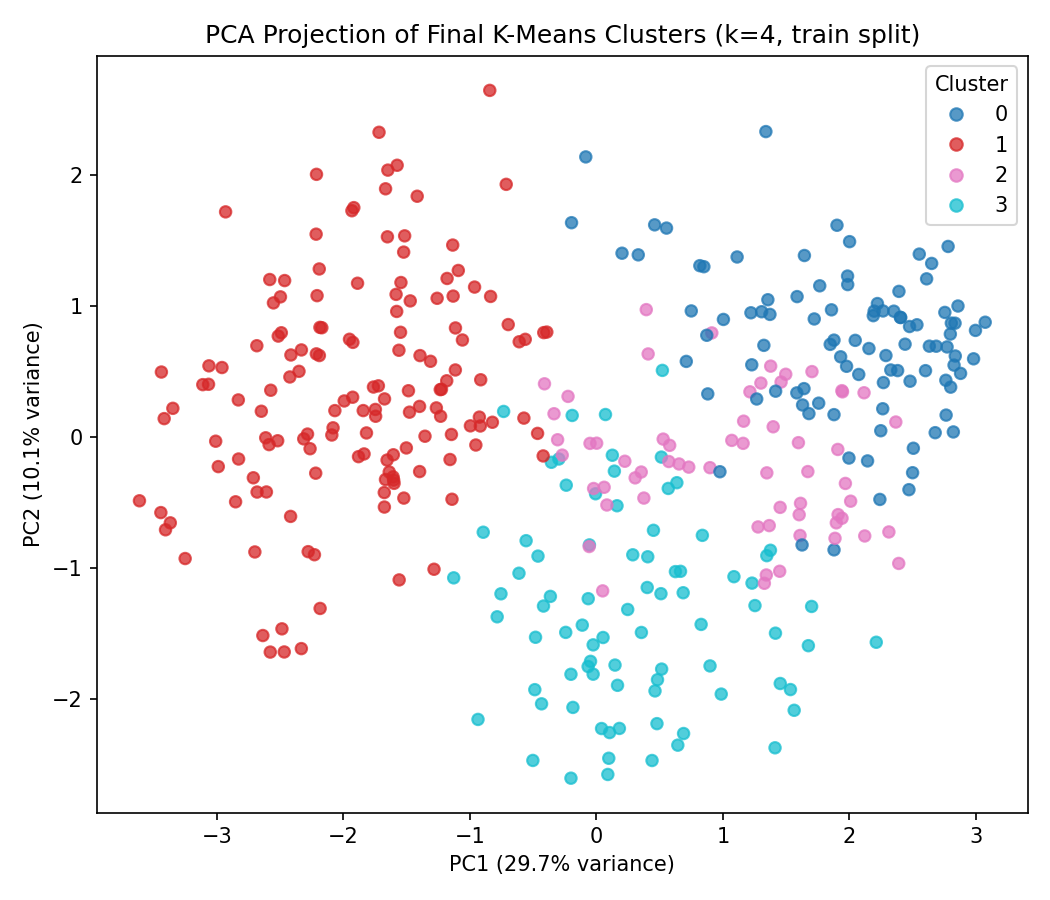

In [23]:
from PIL import Image
Image.open("reports/figures/pca_clusters_train.png")

## Summary

- The saved K-Means model (`models/final_kmeans_model.joblib`) and
  preprocessing pipeline (`models/preprocessor.joblib`) successfully assign
  **brand-new, previously unseen students** to one of four interpretable
  learner segments.
- Invalid inputs (wrong type, out-of-range values, missing fields) are
  caught and reported clearly instead of silently producing a wrong answer.
- Full evaluation results, error analysis, and the justification for
  choosing K-Means with k=4 are in `reports/results.md`.
- Dataset documentation is in `data/README.md`; saved-model documentation is
  in `models/README.md`.